<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Superconducting_CPW_Resonator_Analysis_with_scikit_RF_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Analysis of Superconducting Coplanar Waveguide Resonators via Distributed Circuit Modeling

Quantum microwave circuit design requires a precise mapping between microscopic material properties and macroscopic electromagnetic observables. Predicting the quality factor and resonance frequency of a device demands a bridge between the Bardeen-Cooper-Schrieffer (BCS) theory of superconductivity and microwave network analysis. This notebook implements a reduced-order model to connect these regimes, enabling rapid evaluation of device performance under varying cryogenic conditions.

## 1. Notation and Symbols

| Symbol | Definition | Units |
| :--- | :--- | :---: |
| $f$ | Microwave frequency | $\mathrm{Hz}$ |
| $\omega$ | Angular frequency, $\omega=2\pi f$ | $\mathrm{rad\,s^{-1}}$ |
| $j$ | Imaginary unit, $j^2=-1$ | dimensionless |
| $T$ | Superconductor temperature | $\mathrm{K}$ |
| $T_c$ | Critical temperature | $\mathrm{K}$ |
| $\Delta(T)$ | Temperature-dependent superconducting energy gap | $\mathrm{J}$ |
| $k_B$ | Boltzmann constant | $\mathrm{J\,K^{-1}}$ |
| $\hbar$ | Reduced Planck constant | $\mathrm{J\,s}$ |
| $\rho_n$ | Normal-state resistivity | $\Omega\cdot\mathrm{m}$ |
| $\sigma_n$ | Normal-state conductivity | $\mathrm{S\,m^{-1}}$ |
| $\sigma_1$ | Dissipative component of superconducting conductivity | $\mathrm{S\,m^{-1}}$ |
| $\sigma_2$ | Reactive component of superconducting conductivity | $\mathrm{S\,m^{-1}}$ |
| $\sigma$ | Complex superconducting conductivity | $\mathrm{S\,m^{-1}}$ |
| $\xi$ | Reduced photon-energy parameter, $\hbar\omega/(2k_BT)$ | dimensionless |
| $I_0$ | Modified Bessel function of the first kind, order zero | dimensionless |
| $K_0$ | Modified Bessel function of the second kind, order zero | dimensionless |
| $Z_s$ | Complex superconducting surface impedance | $\Omega$ |
| $R_s$ | Surface resistance | $\Omega$ |
| $X_s$ | Surface reactance | $\Omega$ |
| $t$ | Superconducting film thickness | $\mathrm{m}$ |
| $\mu_0$ | Vacuum permeability | $\mathrm{H\,m^{-1}}$ |
| $\eta_s$ | Effective CPW surface-impedance geometry factor | $\mathrm{m^{-1}}$ |
| $R_{\mathrm{sc}}'$ | Superconducting distributed series resistance | $\Omega\cdot\mathrm{m^{-1}}$ |
| $R'$ | Total distributed series resistance | $\Omega\cdot\mathrm{m^{-1}}$ |
| $L_g'$ | Geometric inductance per unit length | $\mathrm{H\cdot m^{-1}}$ |
| $L_k'$ | Kinetic inductance per unit length | $\mathrm{H\cdot m^{-1}}$ |
| $L'$ | Total inductance per unit length | $\mathrm{H\cdot m^{-1}}$ |
| $G'$ | Distributed shunt conductance | $\mathrm{S\,m^{-1}}$ |
| $C'$ | Distributed capacitance | $\mathrm{F\,m^{-1}}$ |
| $\tan\delta$ | Effective dielectric loss tangent | dimensionless |
| $\alpha_k$ | Kinetic inductance fraction | dimensionless |
| $\gamma$ | Complex propagation constant | $\mathrm{m^{-1}}$ |
| $\alpha$ | Attenuation constant, $\operatorname{Re}(\gamma)$ | $\mathrm{m^{-1}}$ |
| $\beta$ | Phase constant, $\operatorname{Im}(\gamma)$ | $\mathrm{rad\,m^{-1}}$ |
| $Z_c$ | Complex characteristic impedance | $\Omega$ |
| $C_c$ | Feedline-to-resonator coupling capacitance | $\mathrm{F}$ |
| $\ell_r$ | Physical resonator length | $\mathrm{m}$ |
| $f_{\lambda/4}$ | Quarter-wave resonance frequency | $\mathrm{Hz}$ |
| $f_{\mathrm{notch}}$ | Simulated transmission-notch frequency | $\mathrm{Hz}$ |
| $\Delta f$ | Half-depth power linewidth | $\mathrm{Hz}$ |
| $Q_L$ | Loaded quality factor | dimensionless |
| $Q_{\mathrm{int}}$ | Internal quality factor | dimensionless |
| $Q_c$ | Coupling quality factor | dimensionless |
| $S_{21}$ | Forward transmission scattering parameter | dimensionless |

## 2. Superconducting Electrodynamics

Electromagnetic fields in a superconductor drive both the condensate of Cooper pairs and the population of thermally excited quasiparticles. This dual response is captured by the complex conductivity:

$$
\sigma(\omega,T) = \sigma_1(\omega,T) - j\sigma_2(\omega,T)
$$

The real part, $\sigma_1$, governs dissipative losses associated with quasiparticle absorption. The imaginary part, $\sigma_2$, describes the inductive response of the condensate. For conventional superconductors in the low-temperature regime where $k_BT \ll \Delta$ and $\hbar\omega \ll 2\Delta$, the normalized conductivity components follow the Mattis-Bardeen approximations [1]:

$$
\frac{\sigma_1}{\sigma_n} \approx \frac{4\Delta}{\hbar\omega} e^{-\Delta/(k_BT)} \sinh(\xi)K_0(\xi)
$$

$$
\frac{\sigma_2}{\sigma_n} \approx \frac{\pi\Delta}{\hbar\omega} \left[ 1 - 2e^{-\Delta/(k_BT)} e^{-\xi}I_0(\xi) \right]
$$

The dimensionless parameter $\xi$ is defined as:

$$
\xi = \frac{\hbar\omega}{2k_BT}
$$

Temperature-dependent behavior of the energy gap $\Delta(T)$ is approximated via the BCS interpolation:

$$
\Delta(T) \approx 1.764\,k_BT_c \tanh \left[ 1.74 \sqrt{\frac{T_c}{T}-1} \right]
$$

## 3. Material-to-Circuit Mapping

To translate microscopic conductivity into a circuit model, the film is treated as a surface with a finite thickness $t$. The surface impedance $Z_s$ for local electrodynamics is:

$$
Z_s = \sqrt{\frac{j\mu_0\omega}{\sigma}} \coth \left( t\sqrt{j\mu_0\omega\sigma} \right) = R_s + jX_s
$$

This surface response maps to the distributed parameters of a Coplanar Waveguide (CPW) via a geometry factor $\eta_s$. The distributed series resistance $R_{\mathrm{sc}}'$ and kinetic inductance $L_k'$ are derived as:

$$
R_{\mathrm{sc}}' = \eta_s R_s, \quad L_k' = \eta_s \frac{X_s}{\omega}
$$

Total distributed inductance $L'$ comprises both the geometric contribution $L_g'$ and the material-dependent kinetic contribution $L_k'$:

$$
L' = L_g' + L_k'
$$

The relationship between the kinetic inductance fraction $\alpha_k$ and the geometric inductance is given by:

$$
L_{k}' = \frac{\alpha_k}{1-\alpha_k} L_g'
$$

Combined with a distributed shunt conductance $G' = \omega C' \tan\delta$, these quantities define the transmission line's propagation constant $\gamma$ and characteristic impedance $Z_c$:

$$
\gamma = \sqrt{(R' + j\omega L')(G' + j\omega C')}, \quad Z_c = \sqrt{\frac{R' + j\omega L'}{G' + j\omega C'}}
$$

## 4. Hanger Resonator Physics and Temperature Response

The resonator in this model employs a "hanger" topology, where a shorted $\lambda/4$ transmission line is side-coupled to a feedline via a coupling capacitor $C_c$. This configuration produces a distinct notch in the $S_{21}$ transmission spectrum. Its depth and width depend on the ratio of the internal loss rate to the external coupling rate.

Kinetic inductance introduces a non-linear dependence of the resonance frequency on temperature. As temperature rises within the validity range of the low-temperature approximation, the decreasing superfluid density increases the kinetic inductance $L_k'$, generally shifting the quarter-wave resonance toward lower frequencies:

$$
f_{\lambda/4} \propto \frac{1}{\sqrt{L' C'}}
$$

Quantitative modeling close to $T_c$ requires evaluation of the full Mattis–Bardeen conductivity integrals, as the low-temperature approximations lose accuracy near the phase transition.

## 5. Microwave Observables and Quality Factors

The final observable is the complex scattering parameter $S_{21}$. The loaded quality factor $Q_L$ describes the total resonance linewidth and incorporates both internal dissipation and energy exchange with the feedline. For an ideal hanger resonator, it satisfies:

$$
\frac{1}{Q_L} = \frac{1}{Q_{\mathrm{int}}} + \frac{1}{Q_c}
$$

Here, $Q_{\mathrm{int}}$ represents internal resonator loss and $Q_c$ represents external coupling to the feedline. Accordingly, $Q_L$ alone cannot uniquely identify the origin of the measured linewidth.

For an ideal symmetric hanger response, the loaded quality factor can be estimated from the half-depth power linewidth $\Delta f$ according to:

$$
Q_L = \frac{f_{\mathrm{notch}}}{\Delta f}
$$

This linewidth estimator is appropriate for the reduced network model used here. Experimental resonators often require complex $S_{21}$ fitting to account for impedance mismatch, asymmetric coupling, electrical delay, and frequency-dependent backgrounds.

## 6. Model Scope, Assumptions, and Extensions

This reduced-order model provides a computationally efficient complement to full-wave electromagnetic simulation. Full-wave solvers can incorporate superconducting surface impedances or complex conductivities, although resolving the complete electromagnetic geometry across many temperatures and frequencies carries a much greater computational cost. In this implementation, superconducting electrodynamics is reduced to frequency- and temperature-dependent distributed RLGC parameters before `scikit-rf` performs the network calculation. Such separation makes the connection between material response and resonator observables readily accessible while retaining rapid parameter sweeps.

The scalar geometry factor $\eta_s$ compresses the CPW's spatially varying surface-current participation into an effective material-to-circuit mapping. This approximation preserves the principal low-temperature coupling between superconducting surface impedance, kinetic inductance, microwave loss, and resonance frequency without resolving the complete two-dimensional electromagnetic current distribution. A more geometry-specific implementation can replace $\eta_s$ with conformal-mapping expressions or field-solver-derived participation factors.

## References

1. D. C. Mattis and J. Bardeen, “Theory of the Anomalous Skin Effect in Normal and Superconducting Metals,” *Physical Review*, vol. 111, pp. 412–417, 1958. https://doi.org/10.1103/PhysRev.111.412
2. J. Gao, *The Physics of Superconducting Microwave Resonators*, Ph.D. dissertation, California Institute of Technology, 2008. https://doi.org/10.7907/RAT0-VM75
3. J. Zmuidzinas, “Superconducting Microresonators: Physics and Applications,” *Annual Review of Condensed Matter Physics*, vol. 3, pp. 169–214, 2012. https://doi.org/10.1146/annurev-conmatphys-020911-125022
4. scikit-rf, `DistributedCircuit` Documentation, v1.11.0. [Online]. Available: https://scikit-rf.readthedocs.io

In [1]:
!uv pip install --system "scikit-rf==1.11.0" scipy matplotlib

Using Python 3.13.15 environment at: /usr
Resolved 17 packages in 723ms
Prepared 1 package in 111ms
Installed 1 package in 9ms
 + scikit-rf==1.11.0


Material: Al
Temperature: 0.1000 K
Surface geometry factor: 3.055924e+05 1/m
Bare quarter-wave estimate: 5.762214559 GHz
Coupled resonance estimate: 5.691085601 GHz
Simulated S21 minimum: 5.691085601 GHz
Notch depth: -41.029 dB
Loaded Q from half-depth linewidth: 4.421e+03
Distributed internal Q estimate: 4.856e+05
Characteristic impedance at resonance: 54.233 + j0.000 ohm
Kinetic inductance fraction at resonance: 0.150000
Surface resistance at resonance: 2.206925e-12 ohm
Surface reactance at resonance: 8.259709e-03 ohm


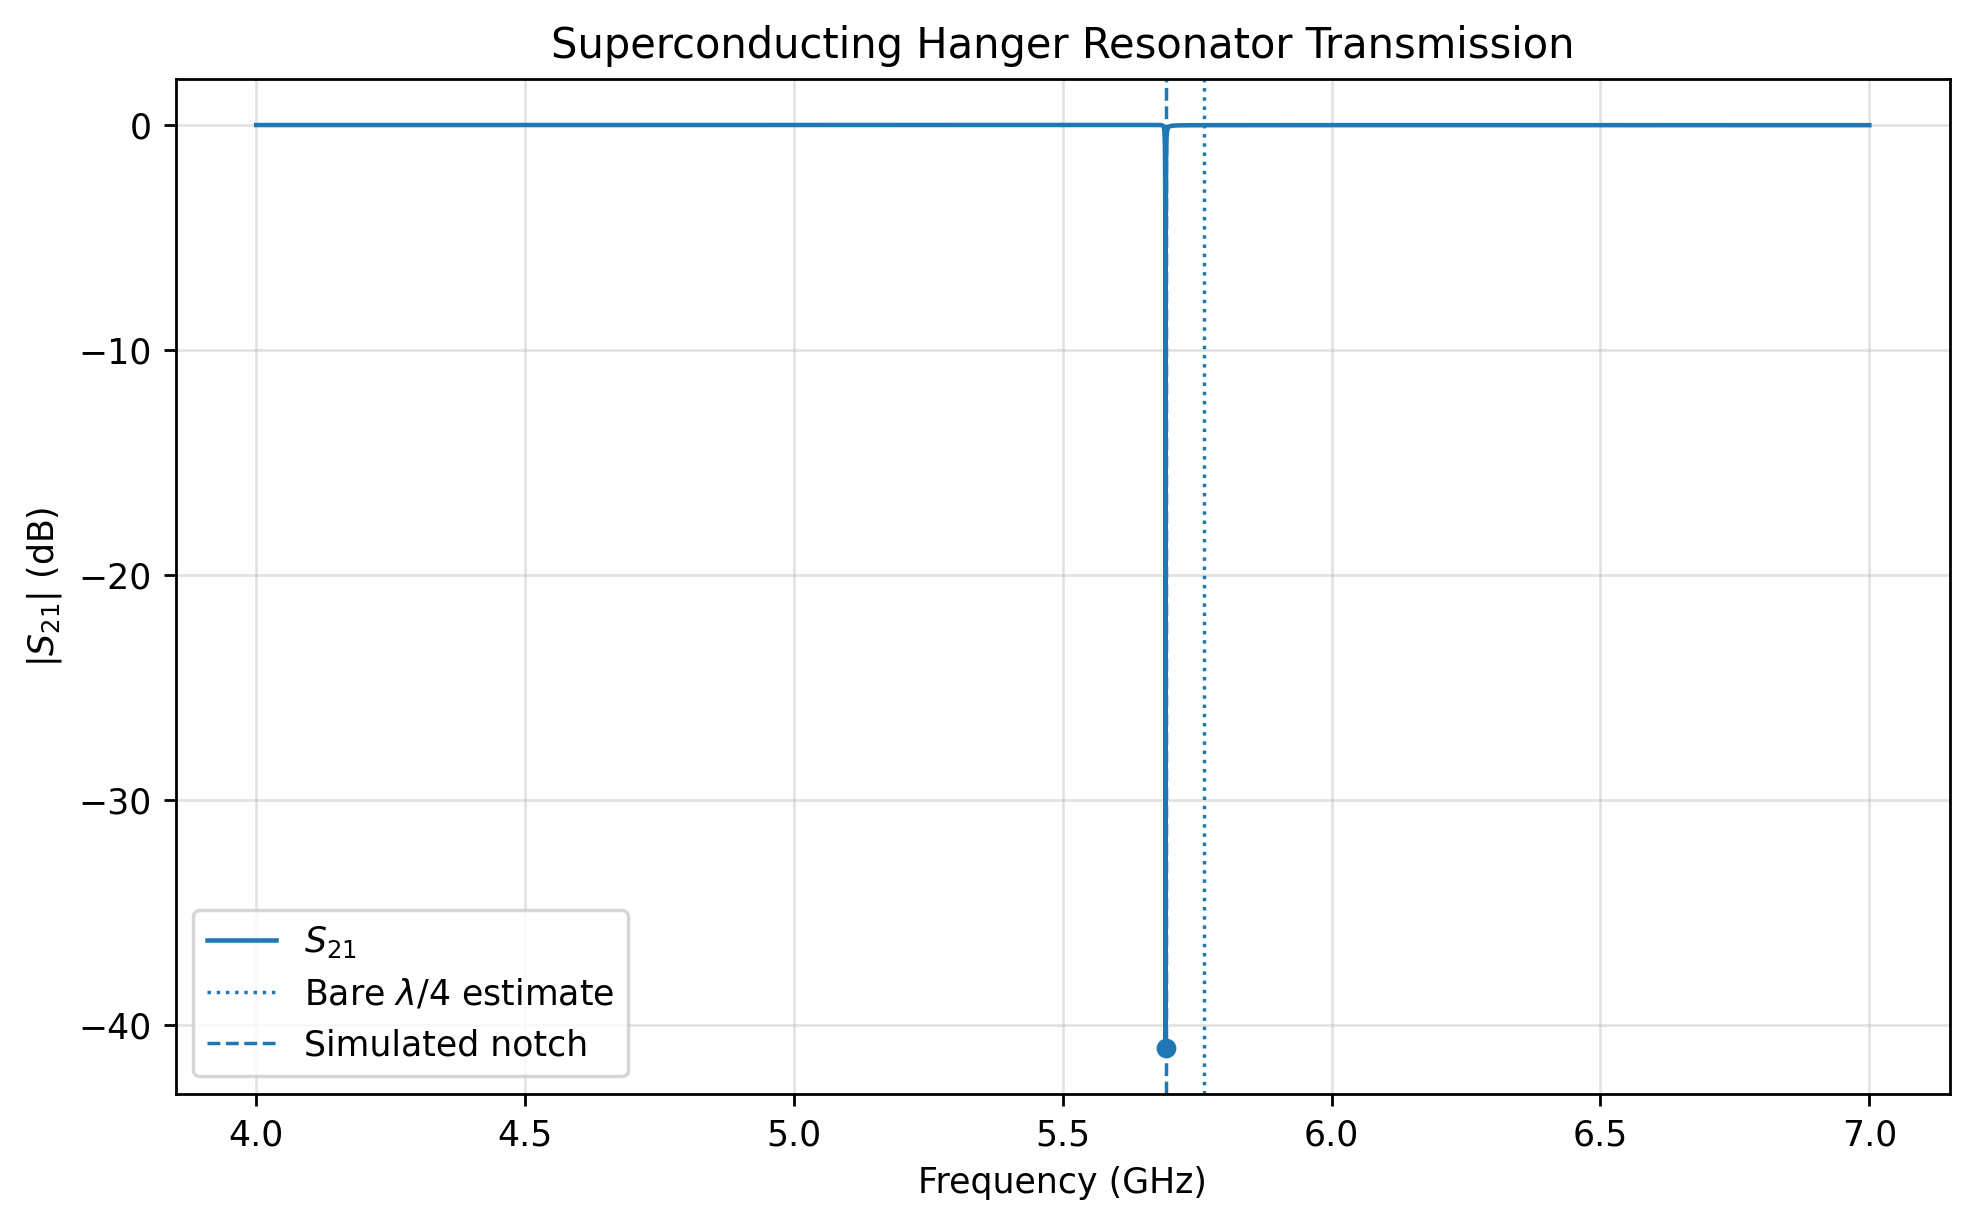

In [2]:
"""Model a superconducting hanger CPW resonator with scikit-rf.

The script maps a low-temperature Mattis-Bardeen conductivity
approximation into a finite-thickness surface impedance. A reference
kinetic inductance fraction then converts the surface response into
frequency-dependent distributed RLGC parameters for scikit-rf.

A coarse frequency sweep is supplemented by dense sampling around the
predicted capacitively coupled quarter-wave resonance.
"""

import warnings
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
from matplotlib import rcParams
from scipy.constants import Boltzmann as K_B
from scipy.constants import hbar as HBAR
from scipy.constants import mu_0 as MU_0
from scipy.optimize import minimize_scalar
from scipy.special import i0e, k0e
from skrf.media import DistributedCircuit


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

SUPERCONDUCTOR_NAME: Final[str] = "Al"

TEMPERATURE_K: Final[float] = 0.10
CRITICAL_TEMPERATURE_K: Final[float] = 1.20
NORMAL_STATE_RESISTIVITY_OHM_M: Final[float] = 2.70e-8
FILM_THICKNESS_M: Final[float] = 200.0e-9

REFERENCE_TEMPERATURE_K: Final[float] = 0.10
REFERENCE_FREQUENCY_HZ: Final[float] = 5.00e9
KINETIC_INDUCTANCE_FRACTION_REFERENCE: Final[float] = 0.15

GEOMETRIC_INDUCTANCE_PER_M: Final[float] = 4.00e-7
CAPACITANCE_PER_M: Final[float] = 1.60e-10
DIELECTRIC_LOSS_TANGENT: Final[float] = 2.00e-6
RESIDUAL_SERIES_RESISTANCE_OHM_PER_M: Final[float] = 1.00e-3

RESONATOR_LENGTH_M: Final[float] = 5.00e-3
FEEDLINE_TOTAL_LENGTH_M: Final[float] = 2.00e-3
COUPLING_CAPACITANCE_F: Final[float] = 10.0e-15
PORT_IMPEDANCE_OHM: Final[float] = 50.0

FREQUENCY_START_HZ: Final[float] = 4.00e9
FREQUENCY_STOP_HZ: Final[float] = 7.00e9

COARSE_FREQUENCY_POINTS: Final[int] = 4001
FINE_FREQUENCY_POINTS: Final[int] = 12001
FINE_FREQUENCY_SPAN_HZ: Final[float] = 60.0e6

FIXED_POINT_ITERATIONS: Final[int] = 20
FIXED_POINT_TOLERANCE: Final[float] = 1.0e-11

PRINT_DIAGNOSTICS: Final[bool] = True


# -----------------------------------------------------------------------------
# Plot configuration
# -----------------------------------------------------------------------------

rcParams["figure.dpi"] = 250
rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
rcParams["font.weight"] = "normal"


# -----------------------------------------------------------------------------
# Superconducting material model
# -----------------------------------------------------------------------------

def calculate_bcs_gap(temperature_k: float) -> float:
    """Calculate the BCS superconducting gap approximation.

    Args:
        temperature_k: Superconductor temperature in kelvin.

    Returns:
        Superconducting energy gap in joules.

    Raises:
        ValueError: If the requested temperature reaches or exceeds Tc.
    """
    if temperature_k <= 0.0:
        return 1.764 * K_B * CRITICAL_TEMPERATURE_K

    if temperature_k >= CRITICAL_TEMPERATURE_K:
        raise ValueError(
            "The superconducting model requires TEMPERATURE_K below Tc."
        )

    reduced_argument = (
        CRITICAL_TEMPERATURE_K / temperature_k - 1.0
    )

    return (
        1.764
        * K_B
        * CRITICAL_TEMPERATURE_K
        * np.tanh(1.74 * np.sqrt(reduced_argument))
    )


def calculate_mattis_bardeen_conductivity(
    frequency_hz: np.ndarray,
    temperature_k: float,
) -> np.ndarray:
    """Calculate a low-temperature Mattis-Bardeen conductivity.

    The implementation uses the common low-temperature, low-photon-energy
    approximation for a conventional BCS superconductor.

    Args:
        frequency_hz: Microwave frequencies in hertz.
        temperature_k: Superconductor temperature in kelvin.

    Returns:
        Complex conductivity sigma1 - j*sigma2 in siemens per meter.

    Raises:
        ValueError: If a frequency is zero or negative.
    """
    frequency_hz = np.asarray(frequency_hz, dtype=float)

    if np.any(frequency_hz <= 0.0):
        raise ValueError("Every frequency must exceed zero.")

    gap_j = calculate_bcs_gap(temperature_k)
    angular_frequency = 2.0 * np.pi * frequency_hz

    xi = (
        HBAR
        * angular_frequency
        / (2.0 * K_B * temperature_k)
    )

    thermal_factor = np.exp(
        -gap_j / (K_B * temperature_k)
    )

    sinh_k0_product = (
        0.5
        * (1.0 - np.exp(-2.0 * xi))
        * k0e(xi)
    )

    sigma_1_normalized = (
        4.0
        * gap_j
        / (HBAR * angular_frequency)
        * thermal_factor
        * sinh_k0_product
    )

    sigma_2_normalized = (
        np.pi
        * gap_j
        / (HBAR * angular_frequency)
        * (
            1.0
            - 2.0
            * thermal_factor
            * i0e(xi)
        )
    )

    normal_conductivity = (
        1.0 / NORMAL_STATE_RESISTIVITY_OHM_M
    )

    return normal_conductivity * (
        sigma_1_normalized
        - 1j * sigma_2_normalized
    )


def calculate_surface_impedance(
    frequency_hz: np.ndarray,
    temperature_k: float,
) -> np.ndarray:
    """Calculate the local finite-thickness surface impedance.

    Args:
        frequency_hz: Microwave frequencies in hertz.
        temperature_k: Superconductor temperature in kelvin.

    Returns:
        Complex surface impedance in ohms.
    """
    frequency_hz = np.asarray(frequency_hz, dtype=float)
    angular_frequency = 2.0 * np.pi * frequency_hz

    conductivity = calculate_mattis_bardeen_conductivity(
        frequency_hz,
        temperature_k,
    )

    propagation_factor = np.sqrt(
        1j
        * MU_0
        * angular_frequency
        * conductivity
    )

    bulk_surface_impedance = np.sqrt(
        1j
        * MU_0
        * angular_frequency
        / conductivity
    )

    thickness_argument = (
        propagation_factor
        * FILM_THICKNESS_M
    )

    return (
        bulk_surface_impedance
        / np.tanh(thickness_argument)
    )


# -----------------------------------------------------------------------------
# CPW material-to-circuit mapping
# -----------------------------------------------------------------------------

def calculate_surface_geometry_factor() -> float:
    """Infer a CPW surface geometry factor from reference alpha_k.

    Returns:
        Surface impedance geometry factor in inverse meters.

    Raises:
        ValueError: If the reference kinetic inductance fraction lies
            outside the physical interval from zero to one.
    """
    alpha_k = KINETIC_INDUCTANCE_FRACTION_REFERENCE

    if alpha_k <= 0.0 or alpha_k >= 1.0:
        raise ValueError(
            "KINETIC_INDUCTANCE_FRACTION_REFERENCE must lie "
            "between zero and one."
        )

    reference_surface_impedance = calculate_surface_impedance(
        np.array([REFERENCE_FREQUENCY_HZ]),
        REFERENCE_TEMPERATURE_K,
    )[0]

    reference_surface_reactance = np.imag(
        reference_surface_impedance
    )

    if reference_surface_reactance <= 0.0:
        raise ValueError(
            "The reference surface reactance must be positive."
        )

    reference_kinetic_inductance = (
        alpha_k
        / (1.0 - alpha_k)
        * GEOMETRIC_INDUCTANCE_PER_M
    )

    reference_angular_frequency = (
        2.0 * np.pi * REFERENCE_FREQUENCY_HZ
    )

    return (
        reference_angular_frequency
        * reference_kinetic_inductance
        / reference_surface_reactance
    )


def calculate_distributed_parameters(
    frequency_hz: np.ndarray,
    temperature_k: float,
    surface_geometry_factor_per_m: float,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """Calculate frequency-dependent CPW RLGC parameters.

    Args:
        frequency_hz: Microwave frequencies in hertz.
        temperature_k: Superconductor temperature in kelvin.
        surface_geometry_factor_per_m: Surface mapping factor.

    Returns:
        Distributed resistance, inductance, conductance, capacitance,
        kinetic inductance, and surface impedance arrays.
    """
    frequency_hz = np.asarray(frequency_hz, dtype=float)
    angular_frequency = 2.0 * np.pi * frequency_hz

    surface_impedance = calculate_surface_impedance(
        frequency_hz,
        temperature_k,
    )

    surface_resistance = np.real(surface_impedance)
    surface_reactance = np.imag(surface_impedance)

    conductor_resistance_per_m = (
        surface_geometry_factor_per_m
        * surface_resistance
    )

    kinetic_inductance_per_m = (
        surface_geometry_factor_per_m
        * surface_reactance
        / angular_frequency
    )

    resistance_per_m = (
        RESIDUAL_SERIES_RESISTANCE_OHM_PER_M
        + conductor_resistance_per_m
    )

    inductance_per_m = (
        GEOMETRIC_INDUCTANCE_PER_M
        + kinetic_inductance_per_m
    )

    capacitance_per_m = np.full_like(
        frequency_hz,
        CAPACITANCE_PER_M,
        dtype=float,
    )

    conductance_per_m = (
        angular_frequency
        * capacitance_per_m
        * DIELECTRIC_LOSS_TANGENT
    )

    return (
        resistance_per_m,
        inductance_per_m,
        conductance_per_m,
        capacitance_per_m,
        kinetic_inductance_per_m,
        surface_impedance,
    )


# -----------------------------------------------------------------------------
# Resonance estimation and adaptive frequency sampling
# -----------------------------------------------------------------------------

def estimate_bare_quarter_wave_frequency(
    temperature_k: float,
    surface_geometry_factor_per_m: float,
) -> float:
    """Estimate the uncoupled quarter-wave resonant frequency.

    Args:
        temperature_k: Superconductor temperature in kelvin.
        surface_geometry_factor_per_m: Surface mapping factor.

    Returns:
        Estimated bare quarter-wave resonance in hertz.
    """
    frequency_hz = REFERENCE_FREQUENCY_HZ

    for _ in range(FIXED_POINT_ITERATIONS):
        (
            _,
            inductance_per_m,
            _,
            capacitance_per_m,
            _,
            _,
        ) = calculate_distributed_parameters(
            np.array([frequency_hz]),
            temperature_k,
            surface_geometry_factor_per_m,
        )

        updated_frequency_hz = (
            1.0
            / (
                4.0
                * RESONATOR_LENGTH_M
                * np.sqrt(
                    inductance_per_m[0]
                    * capacitance_per_m[0]
                )
            )
        )

        relative_change = (
            abs(updated_frequency_hz - frequency_hz)
            / frequency_hz
        )

        frequency_hz = 0.5 * (
            frequency_hz + updated_frequency_hz
        )

        if relative_change < FIXED_POINT_TOLERANCE:
            frequency_hz = updated_frequency_hz
            break

    return float(frequency_hz)


def calculate_branch_impedance(
    frequency_hz: float,
    temperature_k: float,
    surface_geometry_factor_per_m: float,
) -> complex:
    """Calculate the lumped-coupler plus resonator branch impedance.

    Args:
        frequency_hz: Evaluation frequency in hertz.
        temperature_k: Superconductor temperature in kelvin.
        surface_geometry_factor_per_m: Surface mapping factor.

    Returns:
        Complex shunt branch impedance in ohms.
    """
    frequency_array = np.array([frequency_hz], dtype=float)

    (
        resistance_per_m,
        inductance_per_m,
        conductance_per_m,
        capacitance_per_m,
        _,
        _,
    ) = calculate_distributed_parameters(
        frequency_array,
        temperature_k,
        surface_geometry_factor_per_m,
    )

    angular_frequency = 2.0 * np.pi * frequency_hz

    distributed_impedance = (
        resistance_per_m[0]
        + 1j
        * angular_frequency
        * inductance_per_m[0]
    )

    distributed_admittance = (
        conductance_per_m[0]
        + 1j
        * angular_frequency
        * capacitance_per_m[0]
    )

    propagation_constant = np.sqrt(
        distributed_impedance
        * distributed_admittance
    )

    characteristic_impedance = np.sqrt(
        distributed_impedance
        / distributed_admittance
    )

    shorted_line_impedance = (
        characteristic_impedance
        * np.tanh(
            propagation_constant
            * RESONATOR_LENGTH_M
        )
    )

    coupling_capacitor_impedance = (
        1.0
        / (
            1j
            * angular_frequency
            * COUPLING_CAPACITANCE_F
        )
    )

    return (
        coupling_capacitor_impedance
        + shorted_line_impedance
    )


def estimate_coupled_resonance(
    temperature_k: float,
    surface_geometry_factor_per_m: float,
    bare_frequency_hz: float,
) -> float:
    """Estimate the capacitively shifted hanger resonance.

    Args:
        temperature_k: Superconductor temperature in kelvin.
        surface_geometry_factor_per_m: Surface mapping factor.
        bare_frequency_hz: Uncoupled quarter-wave estimate.

    Returns:
        Approximate coupled resonance in hertz.
    """
    lower_bound_hz = max(
        FREQUENCY_START_HZ,
        0.70 * bare_frequency_hz,
    )

    upper_bound_hz = min(
        FREQUENCY_STOP_HZ,
        0.999999 * bare_frequency_hz,
    )

    result = minimize_scalar(
        lambda frequency_hz: abs(
            calculate_branch_impedance(
                frequency_hz,
                temperature_k,
                surface_geometry_factor_per_m,
            )
        ),
        bounds=(lower_bound_hz, upper_bound_hz),
        method="bounded",
        options={"xatol": 0.1},
    )

    return float(result.x)


def build_adaptive_frequency_axis(
    center_frequency_hz: float,
) -> np.ndarray:
    """Build a coarse sweep with dense resonance sampling.

    Args:
        center_frequency_hz: Estimated hanger resonance in hertz.

    Returns:
        Monotonically increasing frequency array in hertz.
    """
    coarse_frequency_hz = np.linspace(
        FREQUENCY_START_HZ,
        FREQUENCY_STOP_HZ,
        COARSE_FREQUENCY_POINTS,
    )

    half_span_hz = 0.5 * FINE_FREQUENCY_SPAN_HZ

    fine_start_hz = max(
        FREQUENCY_START_HZ,
        center_frequency_hz - half_span_hz,
    )

    fine_stop_hz = min(
        FREQUENCY_STOP_HZ,
        center_frequency_hz + half_span_hz,
    )

    fine_frequency_hz = np.linspace(
        fine_start_hz,
        fine_stop_hz,
        FINE_FREQUENCY_POINTS,
    )

    return np.unique(
        np.concatenate(
            (
                coarse_frequency_hz,
                fine_frequency_hz,
            )
        )
    )


# -----------------------------------------------------------------------------
# scikit-rf network construction
# -----------------------------------------------------------------------------

def build_network(
    frequency_hz: np.ndarray,
    temperature_k: float,
    surface_geometry_factor_per_m: float,
) -> tuple[
    rf.Network,
    DistributedCircuit,
    np.ndarray,
    np.ndarray,
]:
    """Build the superconducting hanger resonator network.

    Args:
        frequency_hz: Adaptive frequency array in hertz.
        temperature_k: Superconductor temperature in kelvin.
        surface_geometry_factor_per_m: Surface mapping factor.

    Returns:
        Network, distributed medium, kinetic inductance array, and
        surface impedance array.
    """
    (
        resistance_per_m,
        inductance_per_m,
        conductance_per_m,
        capacitance_per_m,
        kinetic_inductance_per_m,
        surface_impedance,
    ) = calculate_distributed_parameters(
        frequency_hz,
        temperature_k,
        surface_geometry_factor_per_m,
    )

    frequency = rf.Frequency.from_f(
        frequency_hz,
        unit="Hz",
    )
    frequency.unit = "GHz"

    medium = DistributedCircuit(
        frequency=frequency,
        R=resistance_per_m,
        L=inductance_per_m,
        G=conductance_per_m,
        C=capacitance_per_m,
        z0_port=PORT_IMPEDANCE_OHM,
    )

    feedline_half = medium.line(
        d=0.5 * FEEDLINE_TOTAL_LENGTH_M,
        unit="m",
        name="Feedline Half",
    )

    shorted_resonator = medium.delay_short(
        d=RESONATOR_LENGTH_M,
        unit="m",
        name="Shorted Quarter-Wave Resonator",
    )

    coupling_capacitor = medium.capacitor(
        C=COUPLING_CAPACITANCE_F,
        name="Coupling Capacitor",
    )

    resonator_branch = (
        coupling_capacitor
        ** shorted_resonator
    )

    hanger_junction = medium.shunt(
        resonator_branch
    )

    total_network = (
        feedline_half
        ** hanger_junction
        ** feedline_half
    )

    total_network.name = (
        "Superconducting Hanger Resonator"
    )

    return (
        total_network,
        medium,
        kinetic_inductance_per_m,
        surface_impedance,
    )


# -----------------------------------------------------------------------------
# Resonator diagnostics
# -----------------------------------------------------------------------------

def interpolate_crossing(
    frequency_1_hz: float,
    value_1: float,
    frequency_2_hz: float,
    value_2: float,
    target_value: float,
) -> float:
    """Linearly interpolate a spectral threshold crossing.

    Args:
        frequency_1_hz: First frequency.
        value_1: First spectral value.
        frequency_2_hz: Second frequency.
        value_2: Second spectral value.
        target_value: Desired crossing level.

    Returns:
        Interpolated crossing frequency.
    """
    denominator = value_2 - value_1

    if abs(denominator) < np.finfo(float).eps:
        return 0.5 * (
            frequency_1_hz + frequency_2_hz
        )

    fraction = (
        target_value - value_1
    ) / denominator

    return (
        frequency_1_hz
        + fraction
        * (frequency_2_hz - frequency_1_hz)
    )


def estimate_loaded_quality_factor(
    frequency_hz: np.ndarray,
    s21: np.ndarray,
    notch_index: int,
) -> float:
    """Estimate loaded Q from the half-depth power linewidth.

    Args:
        frequency_hz: Frequency array in hertz.
        s21: Complex forward transmission.
        notch_index: Index of the minimum transmission magnitude.

    Returns:
        Approximate loaded quality factor.
    """
    notch_frequency_hz = frequency_hz[notch_index]

    local_mask = (
        np.abs(
            frequency_hz - notch_frequency_hz
        )
        <= 0.5 * FINE_FREQUENCY_SPAN_HZ
    )

    local_frequency_hz = frequency_hz[local_mask]
    local_power = np.abs(s21[local_mask]) ** 2

    local_notch_index = int(
        np.argmin(local_power)
    )

    edge_count = max(
        20,
        local_power.size // 20,
    )

    baseline_power = np.median(
        np.concatenate(
            (
                local_power[:edge_count],
                local_power[-edge_count:],
            )
        )
    )

    minimum_power = local_power[
        local_notch_index
    ]

    half_depth_power = 0.5 * (
        baseline_power + minimum_power
    )

    left_candidates = np.where(
        local_power[:local_notch_index]
        >= half_depth_power
    )[0]

    right_candidates = np.where(
        local_power[local_notch_index:]
        >= half_depth_power
    )[0] + local_notch_index

    if (
        left_candidates.size == 0
        or right_candidates.size == 0
    ):
        return float("nan")

    left_1 = int(left_candidates[-1])
    left_2 = left_1 + 1

    right_2 = int(right_candidates[0])
    right_1 = right_2 - 1

    left_frequency_hz = interpolate_crossing(
        local_frequency_hz[left_1],
        local_power[left_1],
        local_frequency_hz[left_2],
        local_power[left_2],
        half_depth_power,
    )

    right_frequency_hz = interpolate_crossing(
        local_frequency_hz[right_1],
        local_power[right_1],
        local_frequency_hz[right_2],
        local_power[right_2],
        half_depth_power,
    )

    linewidth_hz = (
        right_frequency_hz
        - left_frequency_hz
    )

    if linewidth_hz <= 0.0:
        return float("nan")

    return notch_frequency_hz / linewidth_hz


def check_model_regime(
    frequency_hz: np.ndarray,
    temperature_k: float,
) -> None:
    """Report possible departures from the approximation regime.

    Args:
        frequency_hz: Frequency array in hertz.
        temperature_k: Superconductor temperature in kelvin.
    """
    reduced_temperature = (
        temperature_k
        / CRITICAL_TEMPERATURE_K
    )

    gap_j = calculate_bcs_gap(temperature_k)

    maximum_photon_ratio = np.max(
        HBAR
        * 2.0
        * np.pi
        * frequency_hz
        / (2.0 * gap_j)
    )

    if reduced_temperature > 0.35:
        warnings.warn(
            "Temperature is entering a regime where full "
            "Mattis-Bardeen integrals can improve accuracy.",
            stacklevel=2,
        )

    if maximum_photon_ratio > 0.20:
        warnings.warn(
            "Photon energy is approaching a larger fraction "
            "of the pair-breaking scale.",
            stacklevel=2,
        )


# -----------------------------------------------------------------------------
# Main simulation
# -----------------------------------------------------------------------------

def main() -> None:
    """Execute the superconducting hanger resonator simulation."""
    surface_geometry_factor = (
        calculate_surface_geometry_factor()
    )

    bare_frequency_hz = (
        estimate_bare_quarter_wave_frequency(
            TEMPERATURE_K,
            surface_geometry_factor,
        )
    )

    coupled_frequency_estimate_hz = (
        estimate_coupled_resonance(
            TEMPERATURE_K,
            surface_geometry_factor,
            bare_frequency_hz,
        )
    )

    frequency_hz = build_adaptive_frequency_axis(
        coupled_frequency_estimate_hz
    )

    check_model_regime(
        frequency_hz,
        TEMPERATURE_K,
    )

    (
        total_network,
        medium,
        kinetic_inductance_per_m,
        surface_impedance,
    ) = build_network(
        frequency_hz,
        TEMPERATURE_K,
        surface_geometry_factor,
    )

    s21 = total_network.s[:, 1, 0]
    s21_magnitude = np.abs(s21)

    minimum_positive = np.finfo(float).tiny

    s21_db = 20.0 * np.log10(
        np.maximum(
            s21_magnitude,
            minimum_positive,
        )
    )

    notch_index = int(
        np.argmin(s21_magnitude)
    )

    notch_frequency_hz = frequency_hz[
        notch_index
    ]

    notch_depth_db = s21_db[
        notch_index
    ]

    loaded_quality_factor = (
        estimate_loaded_quality_factor(
            frequency_hz,
            s21,
            notch_index,
        )
    )

    characteristic_impedance = (
        medium.z0_characteristic[notch_index]
    )

    propagation_constant = (
        medium.gamma[notch_index]
    )

    attenuation_per_m = np.real(
        propagation_constant
    )

    phase_constant_per_m = np.imag(
        propagation_constant
    )

    if attenuation_per_m > 0.0:
        distributed_internal_q = (
            phase_constant_per_m
            / (2.0 * attenuation_per_m)
        )
    else:
        distributed_internal_q = float("inf")

    total_inductance_per_m = (
        GEOMETRIC_INDUCTANCE_PER_M
        + kinetic_inductance_per_m
    )

    kinetic_fraction = (
        kinetic_inductance_per_m
        / total_inductance_per_m
    )

    if PRINT_DIAGNOSTICS:
        print(
            f"Material: {SUPERCONDUCTOR_NAME}"
        )
        print(
            f"Temperature: {TEMPERATURE_K:.4f} K"
        )
        print(
            "Surface geometry factor: "
            f"{surface_geometry_factor:.6e} 1/m"
        )
        print(
            "Bare quarter-wave estimate: "
            f"{bare_frequency_hz / 1e9:.9f} GHz"
        )
        print(
            "Coupled resonance estimate: "
            f"{coupled_frequency_estimate_hz / 1e9:.9f} GHz"
        )
        print(
            "Simulated S21 minimum: "
            f"{notch_frequency_hz / 1e9:.9f} GHz"
        )
        print(
            f"Notch depth: {notch_depth_db:.3f} dB"
        )
        print(
            "Loaded Q from half-depth linewidth: "
            f"{loaded_quality_factor:.3e}"
        )
        print(
            "Distributed internal Q estimate: "
            f"{distributed_internal_q:.3e}"
        )
        print(
            "Characteristic impedance at resonance: "
            f"{characteristic_impedance.real:.3f} "
            f"+ j{characteristic_impedance.imag:.3f} ohm"
        )
        print(
            "Kinetic inductance fraction at resonance: "
            f"{kinetic_fraction[notch_index]:.6f}"
        )
        print(
            "Surface resistance at resonance: "
            f"{surface_impedance[notch_index].real:.6e} ohm"
        )
        print(
            "Surface reactance at resonance: "
            f"{surface_impedance[notch_index].imag:.6e} ohm"
        )

    fig, ax = plt.subplots(
        figsize=(8.0, 5.0)
    )

    ax.plot(
        frequency_hz / 1e9,
        s21_db,
        linewidth=1.3,
        label=r"$S_{21}$",
    )

    ax.axvline(
        bare_frequency_hz / 1e9,
        linestyle=":",
        linewidth=1.0,
        label=r"Bare $\lambda/4$ estimate",
    )

    ax.axvline(
        notch_frequency_hz / 1e9,
        linestyle="--",
        linewidth=1.0,
        label="Simulated notch",
    )

    ax.scatter(
        [notch_frequency_hz / 1e9],
        [notch_depth_db],
        s=22.0,
        zorder=3,
    )

    ax.set_title(
        "Superconducting Hanger Resonator Transmission"
    )
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel(r"$|S_{21}|$ (dB)")
    ax.grid(
        True,
        alpha=0.35,
    )
    ax.legend()

    fig.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()